In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


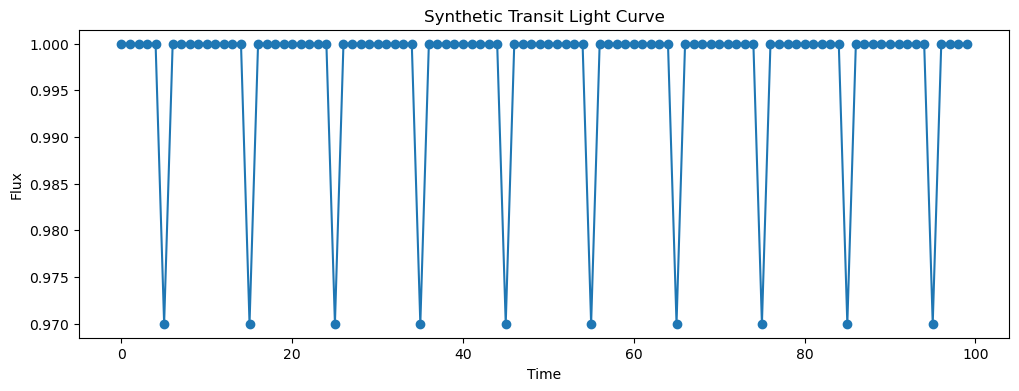

In [4]:
import numpy as np
import matplotlib.pyplot as plt

time = np.arange(0, 100) #light-curve dummy

period = 10
epoch = 5
duration = 2


flux = np.ones_like( # baseline flux
    time,
    dtype=float
)


transit_times = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]

for t in transit_times:
    flux[t] = 0.97


np.random.seed(42)

centroid_x = np.random.normal(
    loc=100,
    scale=0.01,
    size=len(time)
)

centroid_y = np.random.normal(
    loc=200,
    scale=0.01,
    size=len(time)
)



for t in transit_times: # simulate centroid shifts (false positive behaviour)
    centroid_x[t] += 0.05


plt.figure(figsize=(12,4))
plt.plot(time, flux, marker="o")
plt.title("Synthetic Transit Light Curve")
plt.xlabel("Time")
plt.ylabel("Flux")
plt.show()

In [5]:
from src.preprocessing.sample_builder import (
    build_exominer_sample
)

sample = build_exominer_sample(
    time=time,
    flux=flux,
    centroid_x=centroid_x,
    centroid_y=centroid_y,
    period=period,
    epoch=epoch,
    duration=duration
)

for k, v in sample.items():
    print(k)

    if hasattr(v, "shape"):
        print(v.shape)

    print()

full_flux
(200,)

transit_flux
(50,)

full_centroid
(50,)

transit_centroid
(50,)

scalar_features
(5,)

